<h1>E-Commerce Sales Exploratory Data Analysis</h1>

<h2>2. Exploratory Data Analysis</h2>
<b>2.0. IMPORT REQUIRED LIBRARIES</b>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<b>2.1. LOAD THE CLEANED DATASET</b>

In [2]:
file_path = "E:/Project/ecommerce_sales_demand_prediction/data/processed/ecommerce_sales_cleaned.csv"

df = pd.read_csv(file_path)

# Convert Order Date back to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

print("Cleaned dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

display(df.head())

Cleaned dataset loaded successfully!
Dataset shape: (3500, 12)


,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Year,Month,Month Name,Quarter,Day of Week
0,2024-12-31,Printer,Office,North,4,3640,348.93,2024,12,December,4,Tuesday
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,2022,11,November,4,Sunday
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,2022,5,May,2,Wednesday
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,2024,3,March,1,Saturday
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,2022,9,September,3,Saturday


<h3>2.2. Sales Trend Analysis</h3>

<b>2.2.1. MONTHLY SALES TREND</b>

,Year,Month,Sales,Year-Month
0,2022,1,341544,2022-01-01
1,2022,2,208775,2022-02-01
2,2022,3,294660,2022-03-01
3,2022,4,230624,2022-04-01
4,2022,5,314295,2022-05-01


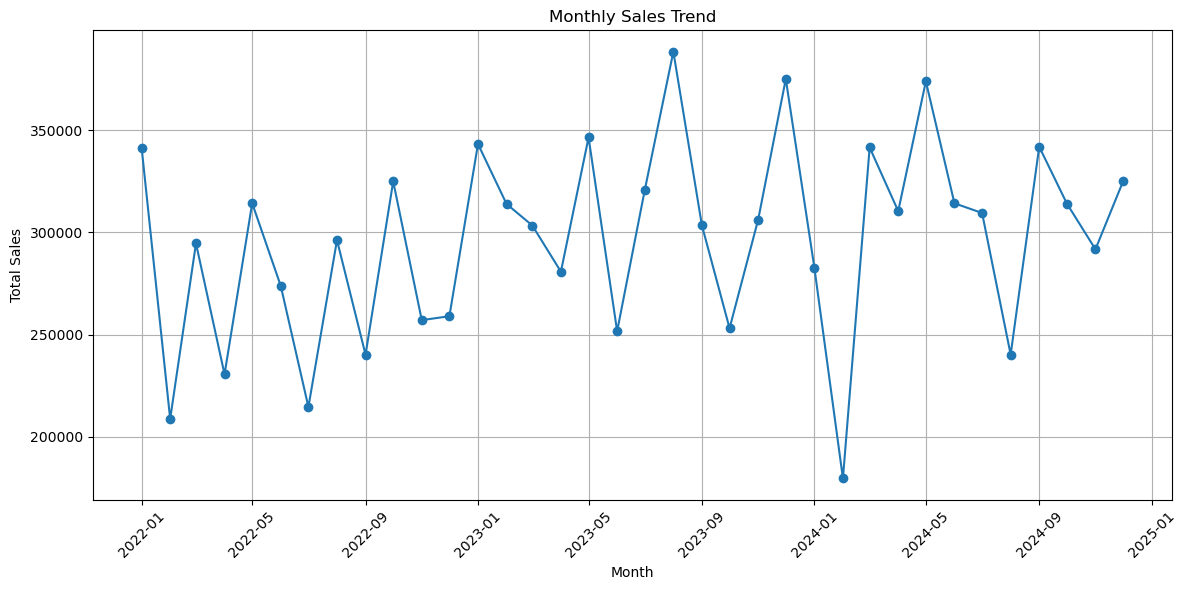

In [3]:
monthly_sales = (
    df.groupby(["Year", "Month"], as_index=False)["Sales"]
    .sum()
)

# Create a proper date column for chronological plotting
monthly_sales["Year-Month"] = pd.to_datetime(
    monthly_sales[["Year", "Month"]].assign(DAY=1)
)

# Sort by date
monthly_sales = monthly_sales.sort_values("Year-Month")

# Display the monthly sales data
display(monthly_sales.head())

# Create the visualization
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Year-Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

<h3>Business Interpretation</h3>
<p><i>
Monthly sales show significant fluctuations throughout the period from 2022 to 2024, with no consistent upward or downward trend. Sales reached their highest level around August 2023, while the lowest sales occurred around February 2024.

These fluctuations suggest that demand may vary across different months due to seasonal patterns, product demand changes, or other business factors. Further analysis of monthly and quarterly demand will help identify whether consistent seasonal patterns exist.</i></p>

<b>2.2.2. YEARLY SALES TREND</b> 

,Year,Sales
0,2022,3255970
1,2023,3786592
2,2024,3625319


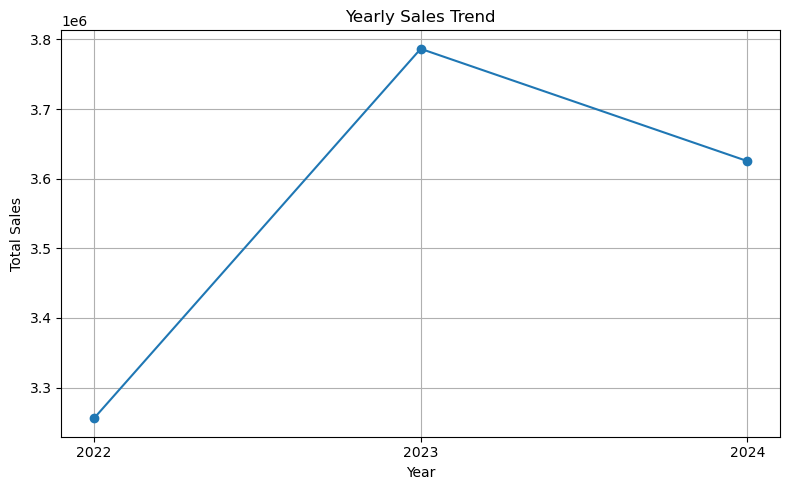

In [4]:
yearly_sales = (
    df.groupby("Year", as_index=False)["Sales"]
    .sum()
)

# Display yearly sales data
display(yearly_sales)

# Create the visualization
plt.figure(figsize=(8, 5))

plt.plot(
    yearly_sales["Year"],
    yearly_sales["Sales"],
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(yearly_sales["Year"])
plt.grid(True)
plt.tight_layout()
plt.show()

<h3>Business Interpretation</h3>
<p><i>
Total sales increased from 3,255,970 in 2022 to 3,786,592 in 2023, representing the strongest annual sales performance during the observed period. Sales decreased slightly to 3,625,319 in 2024 but remained higher than the 2022 level.

Overall, the business showed growth from 2022 to 2023, followed by a moderate decline in 2024. Further analysis of products, regions, and seasonal patterns can help identify the factors contributing to these changes..</i></p>

<h3>2.3. Top-Selling Products</h3>

<b>2.3.1. TOP PRODUCTS BY TOTAL SALES</b>

,Product Name,Sales
0,Camera,1177381
4,Monitor,1160048
6,Printer,1094216
5,Mouse,1074398
7,Smartphone,1069681
8,Smartwatch,1049211
2,Keyboard,1024507
9,Tablet,1023928
3,Laptop,1005873
1,Headphones,988638


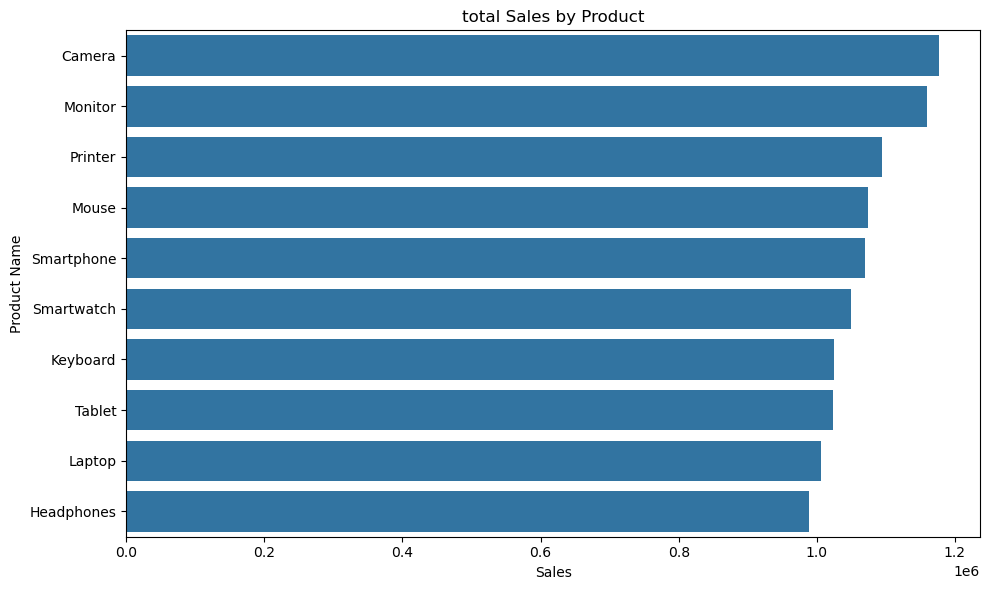

In [5]:
product_sales=(
    df.groupby("Product Name", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)
#Display product sales data
display(product_sales)

#Create the Visualization
plt.figure(figsize=(10,6))
sns.barplot(
    data=product_sales,
    x="Sales",
    y="Product Name"
)

plt.title("total Sales by Product")
plt.xlabel=("Total Sales")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

<h3>Business Interpretation</h3>
<p><i>Camera generated the highest total sales at 1,177,381, followed closely by Monitor at 1,160,048. Headphones generated the lowest total sales at 988,638.

Overall, sales are relatively distributed across the products, but Camera and Monitor are the strongest revenue-generating products. These products may require closer inventory monitoring to ensure sufficient availability.</i></p>

<b>2.3.2. TOP PRODUCTS BY QUANTITY SOLD</b>

,Product Name,Quantity
4,Monitor,1876
8,Smartwatch,1807
0,Camera,1795
5,Mouse,1753
6,Printer,1734
9,Tablet,1733
2,Keyboard,1684
3,Laptop,1658
7,Smartphone,1617
1,Headphones,1604


TypeError: 'str' object is not callable

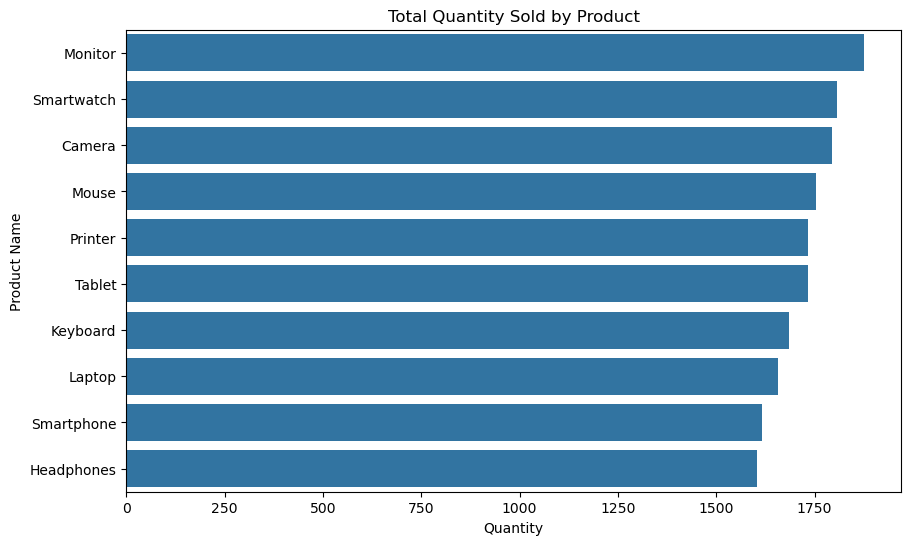

In [6]:
product_quantity = (
    df.groupby("Product Name", as_index=False)["Quantity"]
    .sum()
    .sort_values("Quantity", ascending=False)
)

# Display product quantity data
display(product_quantity)

# Create the visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    data=product_quantity,
    x="Quantity",
    y="Product Name"
)

plt.title("Total Quantity Sold by Product")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

<h3>Business Interpretation</h3>
<p><i>Monitor had the highest quantity sold at 1,876 units, followed by Smartwatch with 1,807 units and Camera with 1,795 units. Headphones had the lowest quantity sold at 1,604 units.

Camera generated the highest total sales, while Monitor had the highest quantity sold. This shows that the product generating the highest revenue is not necessarily the product with the highest demand volume.

For inventory planning, products such as Monitor and Smartwatch may require closer stock monitoring because of their relatively higher sales volume.</i></p>

<h3>2.4. Region-Wise Performance</h3>

<b>2.4.1. REGION-WISE SALES PERFORMANCE<b>

,Region,Sales
3,West,2844450
0,East,2675110
2,South,2659548
1,North,2488773


TypeError: 'str' object is not callable

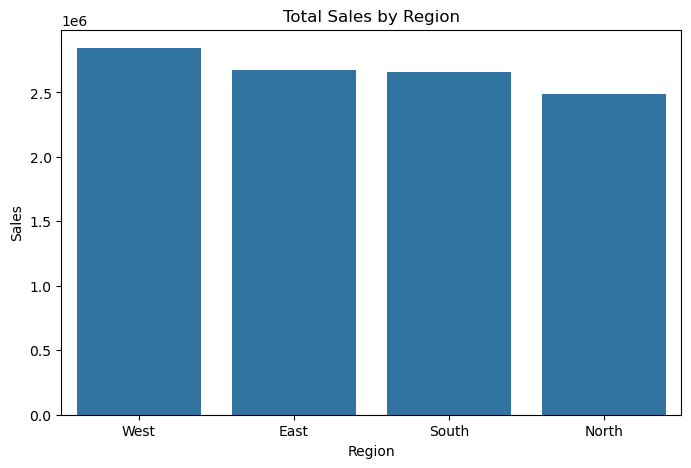

In [7]:
region_sales=(
    df.groupby("Region", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

#Display region-wise Sales data
display(region_sales)

#Create the visualization
plt.figure(figsize=(8,5))
sns.barplot(
    data=region_sales,
    x="Region",
    y="Sales"
)
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

<h3>Business Interpretation</h3>
<p><i>The West region generated the highest total sales at 2,844,450, making it the strongest-performing region in terms of revenue. East and South showed similar sales performance, while North recorded the lowest total sales at 2,488,773.

These results suggest that the West region is currently the strongest market. Further analysis of sales quantity will help determine whether its higher revenue is also supported by higher product demand.</i></p>

<b>2.4.2. REGION-WISE QUANTITY SOLDE<b>

,Region,Quantity
3,West,4488
2,South,4361
0,East,4306
1,North,4106


TypeError: 'str' object is not callable

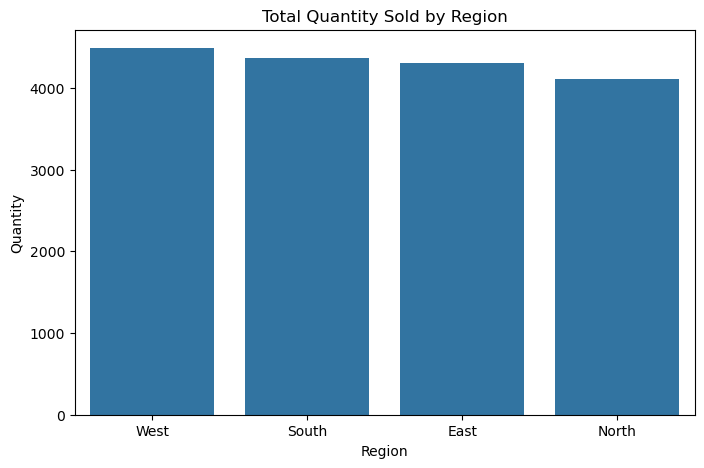

In [8]:
region_quantity = (
    df.groupby("Region", as_index=False)["Quantity"]
    .sum()
    .sort_values("Quantity", ascending=False)
)

# Display region-wise quantity data
display(region_quantity)

# Create the visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    data=region_quantity,
    x="Region",
    y="Quantity"
)

plt.title("Total Quantity Sold by Region")
plt.xlabel("Region")
plt.ylabel("Total Quantity Sold")

plt.tight_layout()
plt.show()

<h3>Business Interpretation</h3>
<p><i>The West region recorded the highest quantity sold at 4,488 units, followed by South with 4,361 units. North had the lowest quantity sold at 4,106 units.

The West region ranks highest in both total sales and quantity sold, indicating strong overall market performance. In contrast, North ranks lowest in both measures, suggesting comparatively lower sales activity during the analyzed period.</i></p>

<h3>2.5. Seasonal Demand Patterns</h3> 

<b>2.5.1 MONTHLY DEMAND PATTERN

,Month,Month Name,Quantity
0,1,January,1507
1,2,February,1138
2,3,March,1532
3,4,April,1394
4,5,May,1613
5,6,June,1426
6,7,July,1411
7,8,August,1499
8,9,September,1399
9,10,October,1449


TypeError: 'str' object is not callable

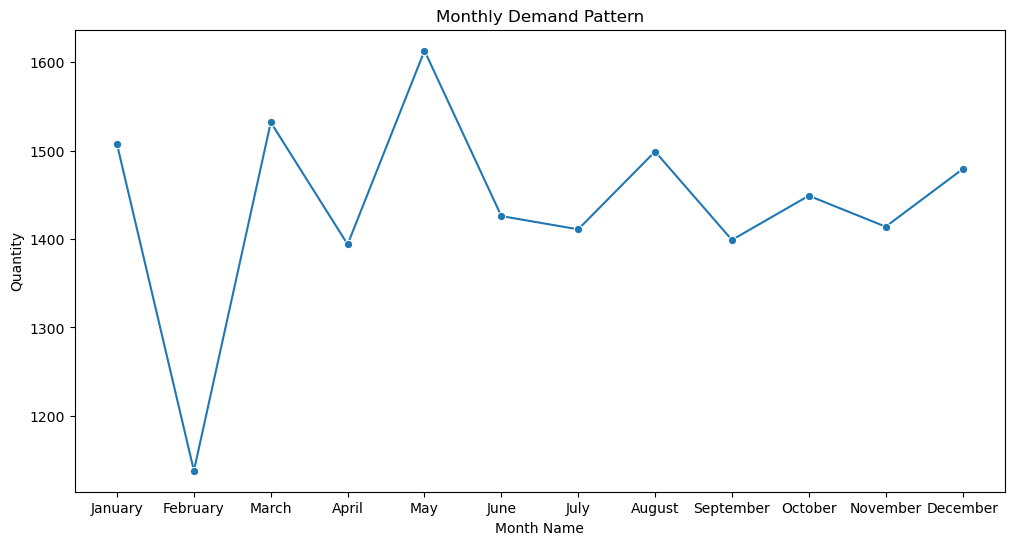

In [10]:
monthly_demand = (
    df.groupby(["Month", "Month Name"], as_index=False)["Quantity"]
    .sum()
    .sort_values("Month")
)

# Display monthly demand data
display(monthly_demand)

# Create the visualization
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_demand,
    x="Month Name",
    y="Quantity",
    marker="o"
)

plt.title("Monthly Demand Pattern")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<h3>Business Interpretation</h3>
<p><i>Monthly demand fluctuates throughout the year. May recorded the highest total quantity sold at 1,613 units, while February had the lowest demand at 1,138 units.

The variation in monthly demand suggests that certain months may experience relatively higher or lower purchasing activity. However, the demand pattern does not show a strong and consistent seasonal trend across all months.</i></p>

<b>2.5.2. QUARTERLY DEMAND PATTERN

,Quarter,Quantity
0,1,4177
1,2,4433
2,3,4309
3,4,4342


TypeError: 'str' object is not callable

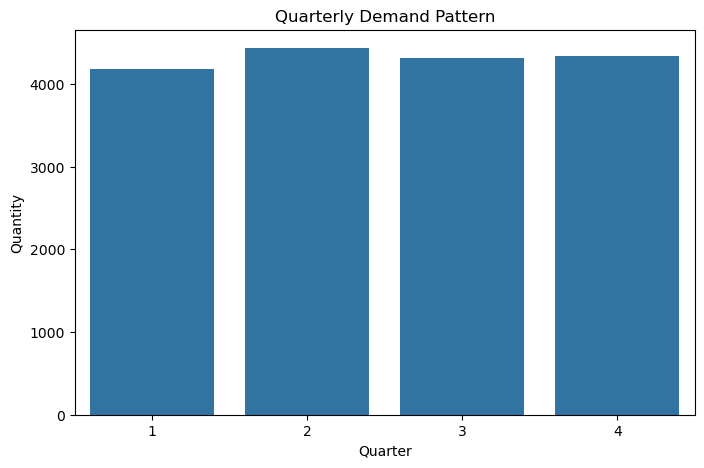

In [12]:
quarterly_demand = (
    df.groupby("Quarter", as_index=False)["Quantity"]
    .sum()
    .sort_values("Quarter")
)

# Display quarterly demand data
display(quarterly_demand)

# Create the visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    data=quarterly_demand,
    x="Quarter",
    y="Quantity"
)

plt.title("Quarterly Demand Pattern")
plt.xlabel("Quarter")
plt.ylabel("Total Quantity Sold")

plt.tight_layout()
plt.show()

<h3>Business Interpretation</h3>
<p><i>Quarter 2 recorded the highest demand with 4,433 units sold, while Quarter 1 had the lowest demand with 4,177 units.

However, demand across all four quarters remains relatively close, indicating that there is no strong quarterly seasonal pattern in the dataset. This suggests that demand is fairly consistent throughout the year, with only moderate fluctuations.</i></p>

<h2 style="text-align: center;">7. Key Business Insights</h2>

1. **Sales Performance:** Total sales increased from **3,255,970 in 2022** to **3,786,592 in 2023**, before declining slightly to **3,625,319 in 2024**. Despite the decline, 2024 sales remained higher than 2022.

2. **Top Revenue-Generating Product:** **Camera** generated the highest total sales at **1,177,381**, followed by **Monitor** at **1,160,048**.

3. **Highest Demand Product:** **Monitor** recorded the highest quantity sold at **1,876 units**, while Camera ranked third in quantity but first in total sales, indicating that higher revenue does not always correspond to higher sales volume.

4. **Regional Performance:** The **West** region was the strongest-performing region, generating the highest sales of **2,844,450** and the highest quantity sold of **4,488 units**.

5. **Lowest Regional Performance:** The **North** region recorded the lowest sales at **2,488,773** and the lowest quantity sold at **4,106 units**.

6. **Monthly Demand Pattern:** **May** recorded the highest monthly demand with **1,613 units**, while **February** had the lowest demand with **1,138 units**.

7. **Quarterly Demand Pattern:** **Quarter 2** recorded the highest demand at **4,433 units**, while **Quarter 1** had the lowest demand at **4,177 units**. Demand remained relatively consistent across all quarters.

8. **Overall Demand Pattern:** The monthly and quarterly analyses show moderate fluctuations, but the dataset does not demonstrate a strong or consistent seasonal demand pattern.
